In [15]:
from pathlib import Path

import pandas as pd


for candidate in (
    Path.cwd(),
    *Path.cwd().parents,
):
    if (
        candidate
        / "pyproject.toml"
    ).is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not locate the repository root. "
        "Expected a parent directory containing "
        "pyproject.toml."
    )


RUN_NAME = (
    "batch1_seed_0_optimized_test_no_smoothing"
)

EVALUATION_NAME = (
    "irregular_object_eval"
)

EVALUATION_ROOT = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
    / RUN_NAME
    / "eval"
    / EVALUATION_NAME
)

OBJECT_METRICS_PATH = (
    EVALUATION_ROOT
    / "object_metrics_per_image_threshold.csv"
)


print(
    "Project root:",
    PROJECT_ROOT,
)

print(
    "Evaluation directory:",
    EVALUATION_ROOT,
)

print(
    "Object metrics:",
    OBJECT_METRICS_PATH,
)

Project root: c:\Users\abd93000\PycharmProjects\cnt_project_v2
Evaluation directory: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\batch1_seed_0_optimized_test_no_smoothing\eval\irregular_object_eval
Object metrics: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\batch1_seed_0_optimized_test_no_smoothing\eval\irregular_object_eval\object_metrics_per_image_threshold.csv


In [16]:
if not OBJECT_METRICS_PATH.is_file():
    raise FileNotFoundError(
        "The object-metrics table does not exist:\n"
        f"{OBJECT_METRICS_PATH}"
    )


object_metrics_df = pd.read_csv(
    OBJECT_METRICS_PATH
)


if object_metrics_df.empty:
    raise RuntimeError(
        "The object-metrics table is empty."
    )


print(
    "Rows:",
    len(object_metrics_df),
)

print(
    "Columns:",
    len(object_metrics_df.columns),
)

print(
    "\nColumn names:"
)

for column in object_metrics_df.columns:
    print(
        f"  - {column}"
    )


display(
    object_metrics_df
)

Rows: 300
Columns: 19

Column names:
  - filename
  - matching_metric
  - threshold
  - num_gt_objects
  - num_pred_objects
  - true_positives
  - false_positives
  - false_negatives
  - precision
  - recall
  - f1_score
  - dsb_precision
  - matched_feature_pair_count
  - irregular_matched_prediction_count
  - mean_absolute_length_error_um
  - mean_absolute_relative_length_error
  - mean_absolute_orientation_error_deg
  - num_pred_objects_before_endpoint_filter
  - num_pred_objects_rejected_by_endpoint_filter


,filename,matching_metric,threshold,num_gt_objects,num_pred_objects,true_positives,false_positives,false_negatives,precision,recall,f1_score,dsb_precision,matched_feature_pair_count,irregular_matched_prediction_count,mean_absolute_length_error_um,mean_absolute_relative_length_error,mean_absolute_orientation_error_deg,num_pred_objects_before_endpoint_filter,num_pred_objects_rejected_by_endpoint_filter
0,1293-22_3_0_20230306224436.tif,cldice,0.1,96,154,91,63,5,0.590909,0.947917,0.728000,0.572327,91,0,0.458693,0.470211,7.223260,154,0
1,1293-22_3_0_20230306224436.tif,cldice,0.2,96,154,91,63,5,0.590909,0.947917,0.728000,0.572327,91,0,0.414281,0.426585,6.757861,154,0
2,1293-22_3_0_20230306224436.tif,cldice,0.3,96,154,90,64,6,0.584416,0.937500,0.720000,0.562500,90,0,0.389096,0.413071,6.357143,154,0
3,1293-22_3_0_20230306224436.tif,cldice,0.4,96,154,84,70,12,0.545455,0.875000,0.672000,0.506024,84,0,0.341246,0.344150,5.508132,154,0
4,1293-22_3_0_20230306224436.tif,cldice,0.5,96,154,73,81,23,0.474026,0.760417,0.584000,0.412429,73,0,0.266194,0.282421,4.703188,154,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,400-1605-W8_map_00049_top_left.tif,cldice,0.6,72,72,40,32,32,0.555556,0.555556,0.555556,0.384615,40,0,0.166577,0.272025,3.650307,72,0
296,400-1605-W8_map_00049_top_left.tif,cldice,0.7,72,72,28,44,44,0.388889,0.388889,0.388889,0.241379,28,0,0.101252,0.171050,2.223057,72,0
297,400-1605-W8_map_00049_top_left.tif,cldice,0.8,72,72,19,53,53,0.263889,0.263889,0.263889,0.152000,19,0,0.056082,0.119142,1.746945,72,0
298,400-1605-W8_map_00049_top_left.tif,cldice,0.9,72,72,7,65,65,0.097222,0.097222,0.097222,0.051095,7,0,0.023477,0.071570,0.431644,72,0


In [17]:
required_columns = {
    "filename",
    "matching_metric",
    "threshold",
    "num_gt_objects",
    "num_pred_objects",
    "true_positives",
    "false_positives",
    "false_negatives",
    "precision",
    "recall",
    "f1_score",
    "dsb_precision",
}


missing_columns = (
    required_columns
    - set(object_metrics_df.columns)
)


if missing_columns:
    raise RuntimeError(
        "The evaluation table is missing expected "
        "columns: "
        + ", ".join(
            sorted(missing_columns)
        )
    )


print(
    "Images:",
    object_metrics_df[
        "filename"
    ].nunique(),
)

print(
    "Matching metrics:",
    object_metrics_df[
        "matching_metric"
    ].unique().tolist(),
)

print(
    "Thresholds:",
    sorted(
        object_metrics_df[
            "threshold"
        ].dropna().unique()
    ),
)


rows_per_image = (
    object_metrics_df
    .groupby("filename")
    .size()
)


print(
    "Rows per image:",
    sorted(
        rows_per_image.unique()
    ),
)


display(
    object_metrics_df.head(10)
)

Images: 30
Matching metrics: ['cldice']
Thresholds: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
Rows per image: [10]


,filename,matching_metric,threshold,num_gt_objects,num_pred_objects,true_positives,false_positives,false_negatives,precision,recall,f1_score,dsb_precision,matched_feature_pair_count,irregular_matched_prediction_count,mean_absolute_length_error_um,mean_absolute_relative_length_error,mean_absolute_orientation_error_deg,num_pred_objects_before_endpoint_filter,num_pred_objects_rejected_by_endpoint_filter
0,1293-22_3_0_20230306224436.tif,cldice,0.1,96,154,91,63,5,0.590909,0.947917,0.728,0.572327,91,0,0.458693,0.470211,7.223260,154,0
1,1293-22_3_0_20230306224436.tif,cldice,0.2,96,154,91,63,5,0.590909,0.947917,0.728,0.572327,91,0,0.414281,0.426585,6.757861,154,0
2,1293-22_3_0_20230306224436.tif,cldice,0.3,96,154,90,64,6,0.584416,0.937500,0.720,0.562500,90,0,0.389096,0.413071,6.357143,154,0
3,1293-22_3_0_20230306224436.tif,cldice,0.4,96,154,84,70,12,0.545455,0.875000,0.672,0.506024,84,0,0.341246,0.344150,5.508132,154,0
4,1293-22_3_0_20230306224436.tif,cldice,0.5,96,154,73,81,23,0.474026,0.760417,0.584,0.412429,73,0,0.266194,0.282421,4.703188,154,0
5,1293-22_3_0_20230306224436.tif,cldice,0.6,96,154,54,100,42,0.350649,0.562500,0.432,0.275510,54,0,0.160871,0.226339,4.255460,154,0
6,1293-22_3_0_20230306224436.tif,cldice,0.7,96,154,47,107,49,0.305195,0.489583,0.376,0.231527,47,0,0.132121,0.206924,4.092022,154,0
7,1293-22_3_0_20230306224436.tif,cldice,0.8,96,154,26,128,70,0.168831,0.270833,0.208,0.116071,26,0,0.095883,0.123856,1.741414,154,0
8,1293-22_3_0_20230306224436.tif,cldice,0.9,96,154,14,140,82,0.090909,0.145833,0.112,0.059322,14,0,0.057017,0.103474,1.042773,154,0
9,1293-22_3_0_20230306224436.tif,cldice,1.0,96,154,3,151,93,0.019481,0.031250,0.024,0.012146,3,0,0.013021,0.038702,0.387872,154,0


In [18]:
# %%
TOP_IMAGE_COUNT = 5


image_mean_f1_df = (
    object_metrics_df
    .groupby(
        "filename",
        as_index=False,
    )
    .agg(
        mean_f1_score=(
            "f1_score",
            "mean",
        ),
        std_f1_score=(
            "f1_score",
            "std",
        ),
        minimum_f1_score=(
            "f1_score",
            "min",
        ),
        maximum_f1_score=(
            "f1_score",
            "max",
        ),
        threshold_count=(
            "threshold",
            "nunique",
        ),
    )
)


if not image_mean_f1_df[
    "threshold_count"
].eq(10).all():
    raise RuntimeError(
        "Some images do not contain exactly "
        "10 matching thresholds."
    )


image_mean_f1_df["filename"] = (
    image_mean_f1_df["filename"]
    .astype(str)
    .map(
        lambda value:
        Path(value).name
    )
)

In [19]:
SPLITS_ROOT = (
    PROJECT_ROOT
    / "data"
    / "cnt_segmentation"
    / "splits"
)


if not SPLITS_ROOT.is_dir():
    raise FileNotFoundError(
        "Split directory does not exist:\n"
        f"{SPLITS_ROOT}"
    )


seed_0_candidate_files = sorted(
    path
    for path in SPLITS_ROOT.rglob("*")
    if (
        path.is_file()
        and "seed_0" in str(path).lower()
        and path.suffix.lower()
        in {
            ".csv",
            ".tsv",
        }
    )
)


if not seed_0_candidate_files:
    raise FileNotFoundError(
        "No seed-0 CSV or TSV split files "
        f"were found under:\n{SPLITS_ROOT}"
    )


print(
    "Candidate seed-0 metadata files:",
    len(seed_0_candidate_files),
)

Candidate seed-0 metadata files: 1


In [20]:
NOISE_METADATA_COLUMNS = {
    "filename",
    "subset",
    "gt_object_count",
    "density_class",
    "noise_sigma",
    "noise_class",
}


metadata_candidates = []


evaluation_filenames = set(
    image_mean_f1_df[
        "filename"
    ]
)


for candidate_path in (
    seed_0_candidate_files
):
    separator = (
        "\t"
        if candidate_path.suffix.lower()
        == ".tsv"
        else ","
    )

    candidate_df = pd.read_csv(
        candidate_path,
        sep=separator,
    )

    if not NOISE_METADATA_COLUMNS.issubset(
        candidate_df.columns
    ):
        continue

    candidate_df = candidate_df.copy()

    candidate_df["filename"] = (
        candidate_df["filename"]
        .astype(str)
        .map(
            lambda value:
            Path(value).name
        )
    )

    candidate_test_df = (
        candidate_df.loc[
            candidate_df[
                "subset"
            ]
            .astype(str)
            .str.strip()
            .str.lower()
            .eq("test")
        ]
        .copy()
    )

    metadata_filenames = set(
        candidate_test_df[
            "filename"
        ]
    )

    if evaluation_filenames.issubset(
        metadata_filenames
    ):
        metadata_candidates.append(
            (
                candidate_path,
                candidate_test_df,
            )
        )


if not metadata_candidates:
    raise RuntimeError(
        "Could not find a seed-0 metadata "
        "table containing all evaluated images."
    )


metadata_path, test_metadata_df = (
    metadata_candidates[0]
)


test_metadata_df = (
    test_metadata_df[
        [
            "filename",
            "subset",
            "gt_object_count",
            "density_class",
            "noise_sigma",
            "noise_class",
        ]
    ]
    .drop_duplicates(
        subset="filename"
    )
)


image_f1_with_metadata_df = (
    image_mean_f1_df.merge(
        test_metadata_df,
        on="filename",
        how="left",
        validate="one_to_one",
    )
)


missing_metadata_df = (
    image_f1_with_metadata_df.loc[
        image_f1_with_metadata_df[
            "noise_class"
        ].isna()
    ]
)


if not missing_metadata_df.empty:
    raise RuntimeError(
        "Noise metadata is missing for:\n"
        + "\n".join(
            missing_metadata_df[
                "filename"
            ].tolist()
        )
    )


clean_image_f1_df = (
    image_f1_with_metadata_df.loc[
        image_f1_with_metadata_df[
            "noise_class"
        ]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("clean")
    ]
    .copy()
)


if len(clean_image_f1_df) < (
    TOP_IMAGE_COUNT
):
    raise RuntimeError(
        f"Only {len(clean_image_f1_df)} clean "
        "images were found, but "
        f"{TOP_IMAGE_COUNT} were requested."
    )


highest_mean_f1_images_df = (
    clean_image_f1_df
    .nlargest(
        TOP_IMAGE_COUNT,
        "mean_f1_score",
    )
    .reset_index(drop=True)
)


highest_mean_f1_images_df.insert(
    0,
    "rank",
    range(
        1,
        len(
            highest_mean_f1_images_df
        ) + 1,
    ),
)


print(
    "Metadata source:",
    metadata_path,
)

print(
    "Evaluated images:",
    len(
        image_f1_with_metadata_df
    ),
)

print(
    "Clean images:",
    len(
        clean_image_f1_df
    ),
)

print(
    "Selected clean images:",
    len(
        highest_mean_f1_images_df
    ),
)


display(
    highest_mean_f1_images_df[
        [
            "rank",
            "filename",
            "mean_f1_score",
            "std_f1_score",
            "minimum_f1_score",
            "maximum_f1_score",
            "density_class",
            "noise_class",
            "noise_sigma",
            "gt_object_count",
        ]
    ]
)

Metadata source: c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\cnt_segmentation\splits\stratified_seed_0.csv
Evaluated images: 30
Clean images: 19
Selected clean images: 5


,rank,filename,mean_f1_score,std_f1_score,minimum_f1_score,maximum_f1_score,density_class,noise_class,noise_sigma,gt_object_count
0,1,400-1293-17-c11k1r5_pd_sp1_2_fl0_1_right.tif,0.822222,0.149989,0.444444,0.888889,Low,Clean,14.084507,5
1,2,400-1293-17-c11k1r5_pd_sp1_2_fl0_1_left.tif,0.777778,0.257193,0.074074,0.888889,Low,Clean,14.084507,14
2,3,400-1293-w14_c05k1r6_sp0_2_flow0_1_top_right.tif,0.707273,0.253743,0.109091,0.890909,Mid,Clean,5.189030,53
3,4,400-1093-w11-c1p1-befo3-10sp-15flow_right.tif,0.659490,0.265574,0.090652,0.883853,High,Clean,5.189030,167
4,5,400-1605-W7_map_00021_4.tif,0.613433,0.266106,0.029851,0.805970,Mid,Clean,11.119348,59


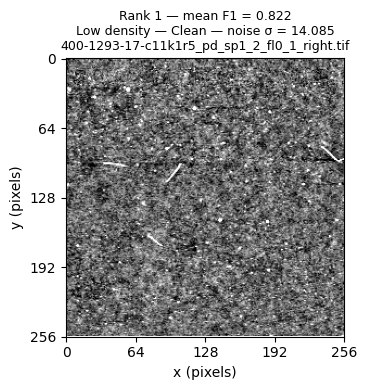

Loaded: c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\cnt_segmentation\images\400-1293-17-c11k1r5_pd_sp1_2_fl0_1_right.tif | shape: (256, 256, 3) | dtype: uint8


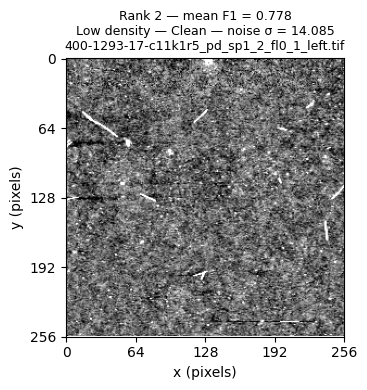

Loaded: c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\cnt_segmentation\images\400-1293-17-c11k1r5_pd_sp1_2_fl0_1_left.tif | shape: (256, 256, 3) | dtype: uint8


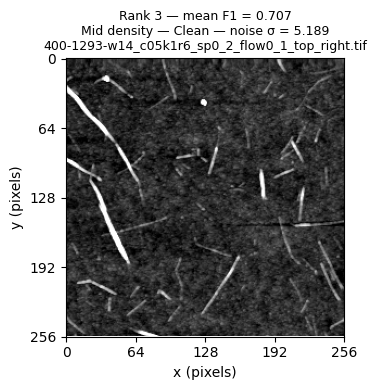

Loaded: c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\cnt_segmentation\images\400-1293-w14_c05k1r6_sp0_2_flow0_1_top_right.tif | shape: (256, 256, 3) | dtype: uint8


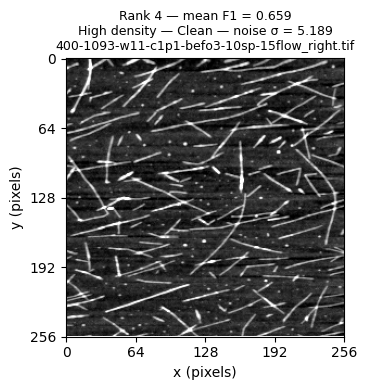

Loaded: c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\cnt_segmentation\images\400-1093-w11-c1p1-befo3-10sp-15flow_right.tif | shape: (256, 256, 3) | dtype: uint8


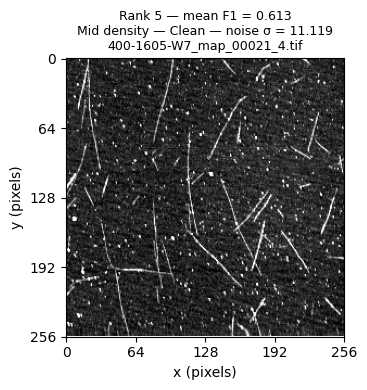

Loaded: c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\cnt_segmentation\images\400-1605-W7_map_00021_4.tif | shape: (256, 256, 3) | dtype: uint8


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import tifffile


IMAGE_ROOT = (
    PROJECT_ROOT
    / "data"
    / "cnt_segmentation"
    / "images"
)


if not IMAGE_ROOT.is_dir():
    raise FileNotFoundError(
        "Image directory does not exist:\n"
        f"{IMAGE_ROOT}"
    )


def resolve_image_path(
    filename,
    *,
    image_root=IMAGE_ROOT,
):
    filename = Path(
        str(filename)
    ).name

    direct_path = (
        image_root
        / filename
    )

    if direct_path.is_file():
        return direct_path

    matches = list(
        image_root.rglob(
            filename
        )
    )

    # Handle filenames stored without an extension.
    if not matches:
        matches = [
            path
            for extension in (
                ".tif",
                ".tiff",
            )
            for path in image_root.rglob(
                f"{Path(filename).stem}"
                f"{extension}"
            )
        ]

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected exactly one image for "
            f"'{filename}', but found "
            f"{len(matches)}:\n"
            + "\n".join(
                str(path)
                for path in matches
            )
        )

    return matches[0]


def normalize_image_for_display(
    image,
):
    image = np.asarray(
        image
    )

    if (
        image.ndim == 3
        and image.shape[-1] == 1
    ):
        image = image[..., 0]

    image = image.astype(
        np.float64
    )

    lower, upper = np.percentile(
        image,
        [
            1,
            99,
        ],
    )

    if upper > lower:
        image = np.clip(
            (image - lower)
            / (upper - lower),
            0.0,
            1.0,
        )
    else:
        image = np.zeros_like(
            image,
            dtype=np.float64,
        )

    return image


for _, row in (
    highest_mean_f1_images_df
    .sort_values("rank")
    .iterrows()
):
    image_path = resolve_image_path(
        row["filename"]
    )

    image = tifffile.imread(
        image_path
    )

    display_image = (
        normalize_image_for_display(
            image
        )
    )

    figure, axis = plt.subplots(
        figsize=(
            4.5,
            4.0,
        )
    )

    axis.imshow(
        display_image,
        cmap=(
            "gray"
            if display_image.ndim == 2
            else None
        ),
    )

    axis.set_title(
        (
            f"Rank {int(row['rank'])} — "
            f"mean F1 = "
            f"{row['mean_f1_score']:.3f}\n"
            f"{row['density_class']} density — "
            f"{row['noise_class']} — "
            f"noise σ = "
            f"{row['noise_sigma']:.3f}\n"
            f"{Path(row['filename']).name}"
        ),
        fontsize=9,
    )

    axis.set_xlabel(
        "x (pixels)"
    )

    axis.set_ylabel(
        "y (pixels)"
    )

    axis.set_xticks(
        np.arange(
            0,
            display_image.shape[1] + 1,
            64,
        )
    )

    axis.set_yticks(
        np.arange(
            0,
            display_image.shape[0] + 1,
            64,
        )
    )

    figure.tight_layout()

    plt.show()

    print(
        "Loaded:",
        image_path,
        "| shape:",
        image.shape,
        "| dtype:",
        image.dtype,
    )

In [22]:
print(
    "Selected clean image filenames:"
)


for filename in (
    highest_mean_f1_images_df
    .sort_values("rank")[
        "filename"
    ]
):
    print(filename)

Selected clean image filenames:
400-1293-17-c11k1r5_pd_sp1_2_fl0_1_right.tif
400-1293-17-c11k1r5_pd_sp1_2_fl0_1_left.tif
400-1293-w14_c05k1r6_sp0_2_flow0_1_top_right.tif
400-1093-w11-c1p1-befo3-10sp-15flow_right.tif
400-1605-W7_map_00021_4.tif
